# Objectif 

Très court notebook pour illustré les variations du nombre de modes en fonction des paramètres du guide de Pekeris. 

Pour rappel : 
$$
M = \left\lfloor \frac{2 D f \sqrt{1 - (\frac{c_1}{c_2})^2}}{c_1}   + \frac{1}{2} \right\rfloor
$$


In [13]:
import sys
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
root_project = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(root_project)

from illustration_rtf.src.sensitivity import baseline_env, baseline_sig, baseline_src_rcv
from publication.publication_figure import color, set_subfigures_abc_labels

# Chargement de l'environnement 

In [6]:
# Environment
env_param = baseline_env()
print("Baseline environement properties:")
for k in env_param.keys():
    print(f"\t{k} = {env_param[k]}")

# Signal
sig_param = baseline_sig()
print("Baseline signal properties:")
for k in sig_param.keys():
    print(f"\t{k} = {sig_param[k]}")

# Source receiver config
src_rcv_param = baseline_src_rcv()
print("Baseline src / rcv configuration:")
for k in src_rcv_param.keys():
    print(f"\t{k} = {src_rcv_param[k]}")

Baseline environement properties:
	c_w = 1500
	c_s = 1600
	rho_w = 1000.0
	rho_s = 1500.0
	depth = 100
Baseline signal properties:
	freq = [  0.    0.2   0.4   0.6   0.8   1.    1.2   1.4   1.6   1.8   2.    2.2
   2.4   2.6   2.8   3.    3.2   3.4   3.6   3.8   4.    4.2   4.4   4.6
   4.8   5.    5.2   5.4   5.6   5.8   6.    6.2   6.4   6.6   6.8   7.
   7.2   7.4   7.6   7.8   8.    8.2   8.4   8.6   8.8   9.    9.2   9.4
   9.6   9.8  10.   10.2  10.4  10.6  10.8  11.   11.2  11.4  11.6  11.8
  12.   12.2  12.4  12.6  12.8  13.   13.2  13.4  13.6  13.8  14.   14.2
  14.4  14.6  14.8  15.   15.2  15.4  15.6  15.8  16.   16.2  16.4  16.6
  16.8  17.   17.2  17.4  17.6  17.8  18.   18.2  18.4  18.6  18.8  19.
  19.2  19.4  19.6  19.8  20.   20.2  20.4  20.6  20.8  21.   21.2  21.4
  21.6  21.8  22.   22.2  22.4  22.6  22.8  23.   23.2  23.4  23.6  23.8
  24.   24.2  24.4  24.6  24.8  25.   25.2  25.4  25.6  25.8  26.   26.2
  26.4  26.6  26.8  27.   27.2  27.4  27.6  27.8  28.   28.2

In [8]:
# Environment
c_w = env_param.get("c_w", None)
c_s = env_param.get("c_s", None)
d = env_param.get("depth", None)

# Signal
fmax = sig_param.get("fmax", None)

# Plage de valeurs

In [9]:
npt = int(1e3)

# In water
c_w_min = 1400
c_w_max = 1550
c_w_test = np.linspace(c_w_min, c_w_max, npt) 

# Tableau 1.3, Jensen p.39
c_s_min = 1500      # Clay
c_s_max = 5250      # Basalt 
c_s_test = np.linspace(c_s_min, c_s_max, npt) 

# Depth
d_min = 10
d_max = 5000
d_test = np.linspace(d_min, d_max, npt)

# Central frequency of the baseline waveguide 
f = fmax / 2

# Variations de M 

In [16]:
def pekeris_n_modes(f, c_w, c_s, d):
    """Calculate the number of propagating modes in a Pekeris waveguide."""
    # Equivalent to Eq. 2.191, Jensen p. 125 or Eq. 8.89, Jensen p.637
    n_max = np.int32(np.floor(2 * d / c_w * np.sqrt(1 - (c_w / c_s) ** 2) * f + 1 / 2))
    return n_max

In [17]:
M_c1 = pekeris_n_modes(f, c_w=c_w_test, c_s=c_s, d=d)
M_c2 = pekeris_n_modes(f, c_w=c_w, c_s=c_s_test, d=d)
M_d = pekeris_n_modes(f, c_w=c_w, c_s=c_s, d=d_test)

Text(0.02, 0.5, 'M')

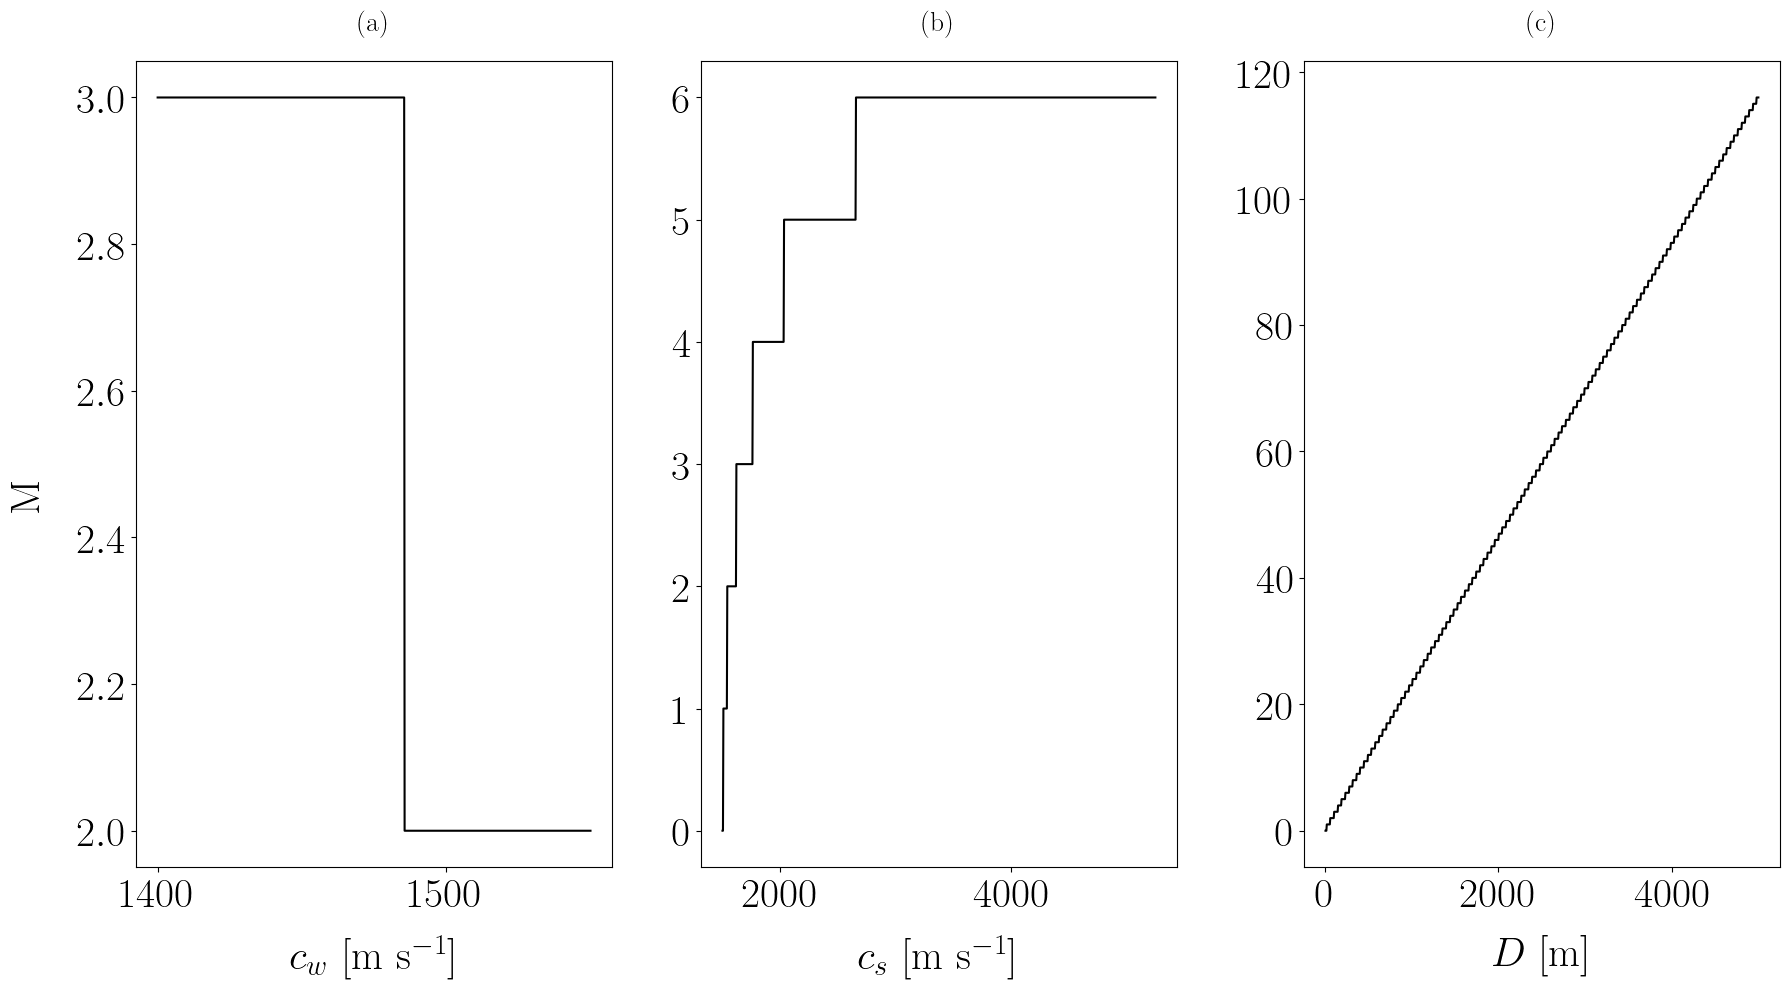

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(18, 10), sharey=False)

axs[0].plot(c_w_test, M_c1, color="k")
axs[0].set_xlabel("$c_1$ [m~s$^{-1}$]")
axs[1].plot(c_s_test, M_c2, color="k")
axs[1].set_xlabel("$c_2$ [m~s$^{-1}$]")
axs[2].plot(d_test, M_d, color="k")
axs[2].set_xlabel("$D$ [m]")


set_subfigures_abc_labels(
    axs, x_pos=0.5, y_pos=1.03, fontsize=20, ha="center", va="bottom"
)

fig.supylabel("M")